home_team='Bayer 04 Leverkusen' away_team='Paris Saint-Germain FC' url='https://dataviz.theanalyst.com/opta-football-match-centre/?competitionId=4oogyu6o156iphvdvphwpck10&seasonId=2mr0u0l78k2gdsm79q56tb2fo&matchId=559m5skeluuo83bn5qad6rggk#tab-team-stats'
Tải dữ liệu thành công.
Dữ liệu gốc có 623 điểm. Dữ liệu sau khi lọc ngoại lệ có 623 điểm.
Đã lưu biểu đồ toàn trận vào 'momentum_full_match_first_half.png'
Đã lưu biểu đồ 10 phút vào 'momentum_10min_intervals_first_half.png'


/tmp/ipykernel_384211/1905868197.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = df_filtered.groupby('time_bin')['momentum_index'].mean().reset_index()


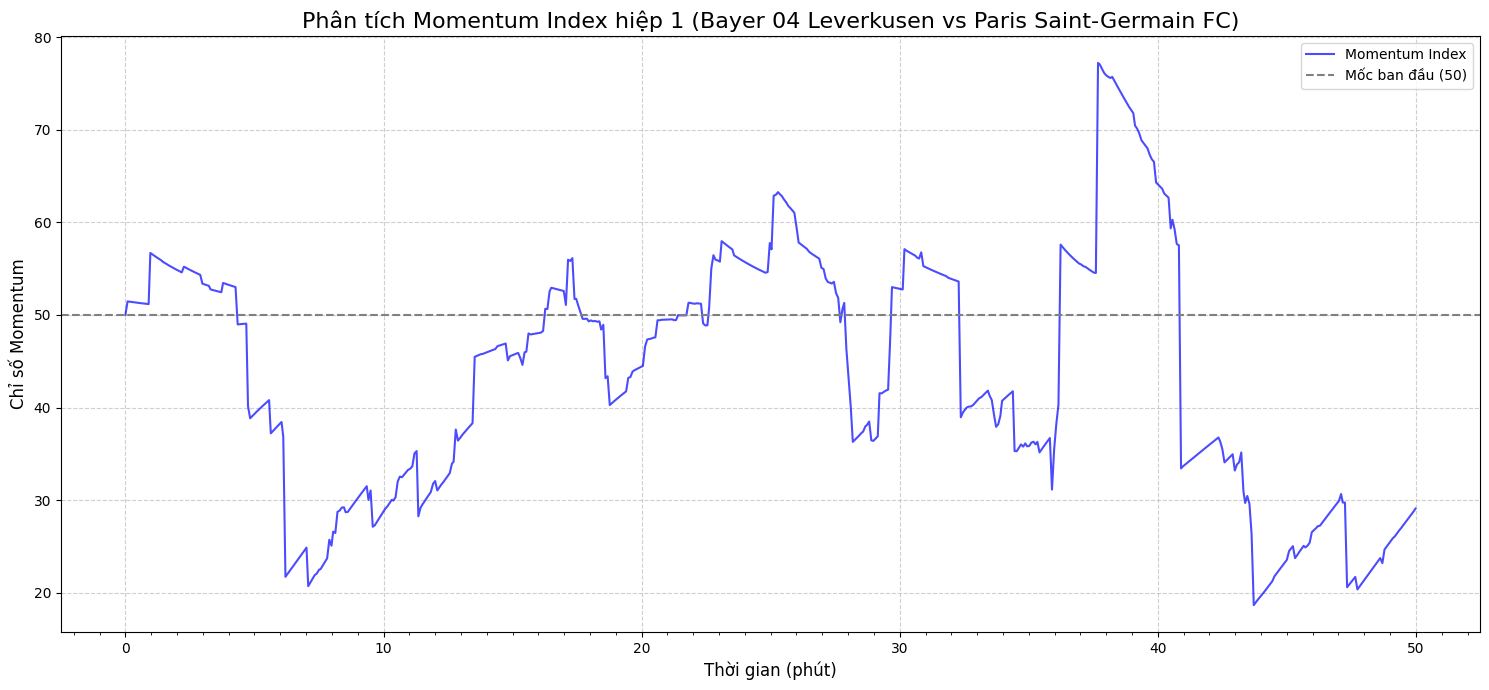

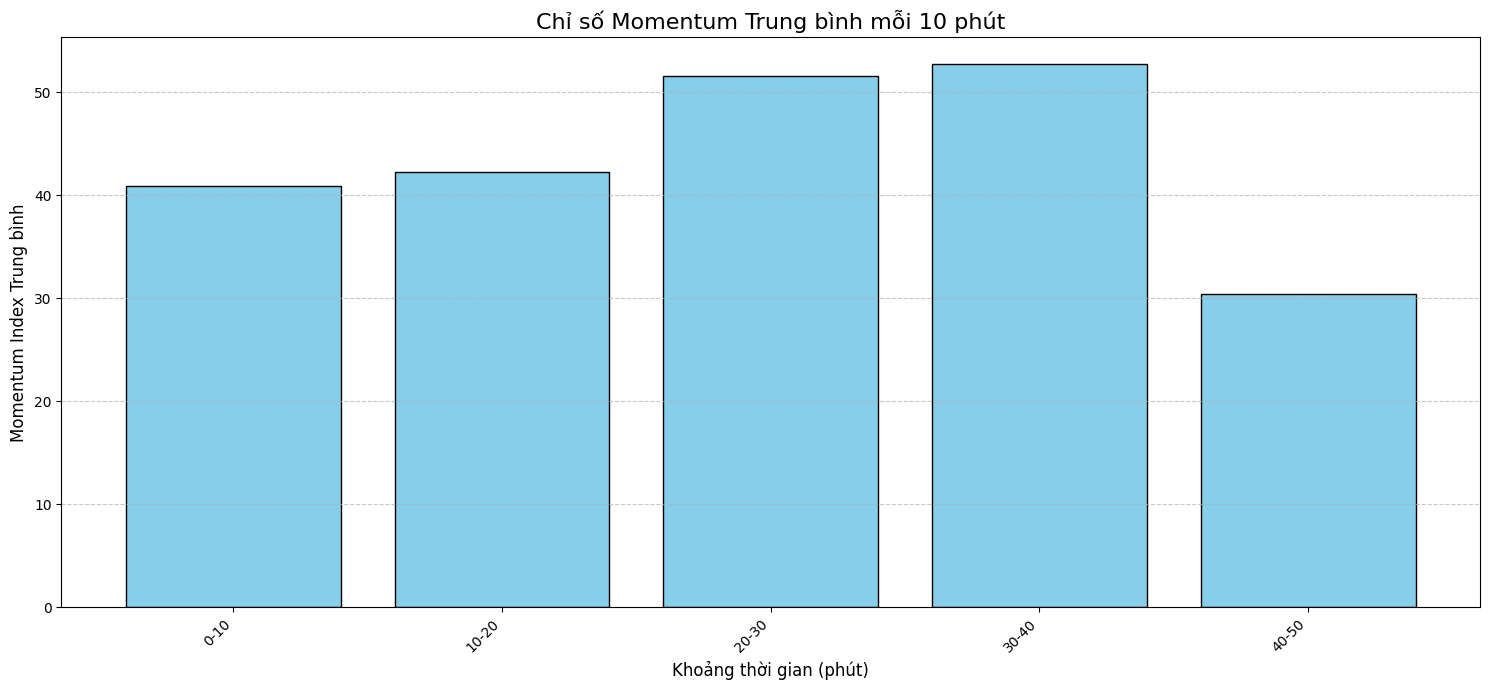

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from configs import match_config

print(match_config)

# 1. Hàm để chuyển đổi 'time_in_match' sang giây
def parse_time_to_seconds(time_str):
    """
    Chuyển đổi chuỗi thời gian (ví dụ: "1:05", "45+1:08") sang tổng số giây.
    """
    try:
        if '+' in time_str:
            # Xử lý thời gian bù giờ, ví dụ: "45+1:08"
            main_parts = time_str.split('+')
            main_minutes = int(main_parts[0])
            stoppage_parts = main_parts[1].split(':')
            stoppage_minutes = int(stoppage_parts[0])
            stoppage_seconds = int(stoppage_parts[1])
            total_seconds = (main_minutes * 60) + (stoppage_minutes * 60) + stoppage_seconds
        else:
            # Xử lý thời gian thông thường, ví dụ: "7:10"
            parts = time_str.split(':')
            minutes = int(parts[0])
            seconds = int(parts[1])
            total_seconds = (minutes * 60) + seconds
        return total_seconds
    except Exception as e:
        print(f"Lỗi khi xử lý thời gian: {time_str} - {e}")
        return None

# 2. Tải và chuẩn bị dữ liệu
try:
    df = pd.read_json('momentum_index_first_half.json')
    print("Tải dữ liệu thành công.")
    
    # Áp dụng hàm chuyển đổi thời gian
    df['total_seconds'] = df['time_in_match'].apply(parse_time_to_seconds)
    df['total_minutes'] = df['total_seconds'] / 60
    
    # Sắp xếp lại dữ liệu theo thời gian (quan trọng cho biểu đồ đường)
    df = df.sort_values(by='total_seconds').reset_index(drop=True)

    # Phát hiện và lọc các giá trị ngoại lệ (outliers)
    # Có một giá trị -80225.97 rất lớn, ta sẽ lọc nó
    df_filtered = df[df['momentum_index'] > -10000].copy()
    print(f"Dữ liệu gốc có {len(df)} điểm. Dữ liệu sau khi lọc ngoại lệ có {len(df_filtered)} điểm.")

    # 3. Biểu đồ 1: Visualize toàn bộ trận đấu
    plt.figure(figsize=(15, 7))
    plt.plot(df_filtered['total_minutes'], df_filtered['momentum_index'], label='Momentum Index', color='blue', alpha=0.7)
    
    # Thêm đường 50 (mốc bắt đầu)
    plt.axhline(y=50, color='grey', linestyle='--', label='Mốc ban đầu (50)')
    
    # Định dạng trục x để hiển thị phút rõ ràng
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
    plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(1))

    plt.title(f"Phân tích Momentum Index hiệp 1 ({match_config.home_team} vs {match_config.away_team})", fontsize=16)
    plt.xlabel('Thời gian (phút)', fontsize=12)
    plt.ylabel('Chỉ số Momentum', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig('momentum_full_match_first_half.png')
    print("Đã lưu biểu đồ toàn trận vào 'momentum_full_match_first_half.png'")

    # 4. Biểu đồ 2: Visualize theo khoảng 10 phút (trung bình)
    
    # Tạo các khoảng 10 phút (600 giây)
    max_seconds = int(df_filtered['total_seconds'].max())
    # Đảm bảo bin cuối cùng bao gồm cả điểm dữ liệu cuối cùng
    bins = list(range(0, max_seconds + 600, 600))
    
    # Tạo nhãn cho các khoảng, ví dụ: "0-10", "10-20"
    labels = [f'{i // 60}-{(i + 600) // 60}' for i in bins[:-1]]
    
    # Thêm cột 'time_bin' vào dataframe đã lọc
    df_filtered['time_bin'] = pd.cut(df_filtered['total_seconds'], bins=bins, labels=labels, right=False)
    
    # Tính toán momentum trung bình cho mỗi khoảng thời gian
    summary_df = df_filtered.groupby('time_bin')['momentum_index'].mean().reset_index()

    # Vẽ biểu đồ cột
    plt.figure(figsize=(15, 7))
    plt.bar(summary_df['time_bin'], summary_df['momentum_index'], color='skyblue', edgecolor='black')
    
    plt.title('Chỉ số Momentum Trung bình mỗi 10 phút', fontsize=16)
    plt.xlabel('Khoảng thời gian (phút)', fontsize=12)
    plt.ylabel('Momentum Index Trung bình', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('momentum_10min_intervals_first_half.png')
    print("Đã lưu biểu đồ 10 phút vào 'momentum_10min_intervals_first_half.png'")

except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'momentum_index_first_half.json'.")
except Exception as e:
    print(f"Đã xảy ra lỗi: {e}")

Tải dữ liệu thành công.
Dữ liệu gốc có 609 điểm. Dữ liệu sau khi lọc ngoại lệ có 609 điểm.
Đã lưu biểu đồ toàn trận vào 'momentum_full_match_second_half.png'


/tmp/ipykernel_384211/2003792467.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = df_filtered.groupby('time_bin')['momentum_index'].mean().reset_index()


Đã lưu biểu đồ 10 phút vào 'momentum_10min_intervals_second_half.png'


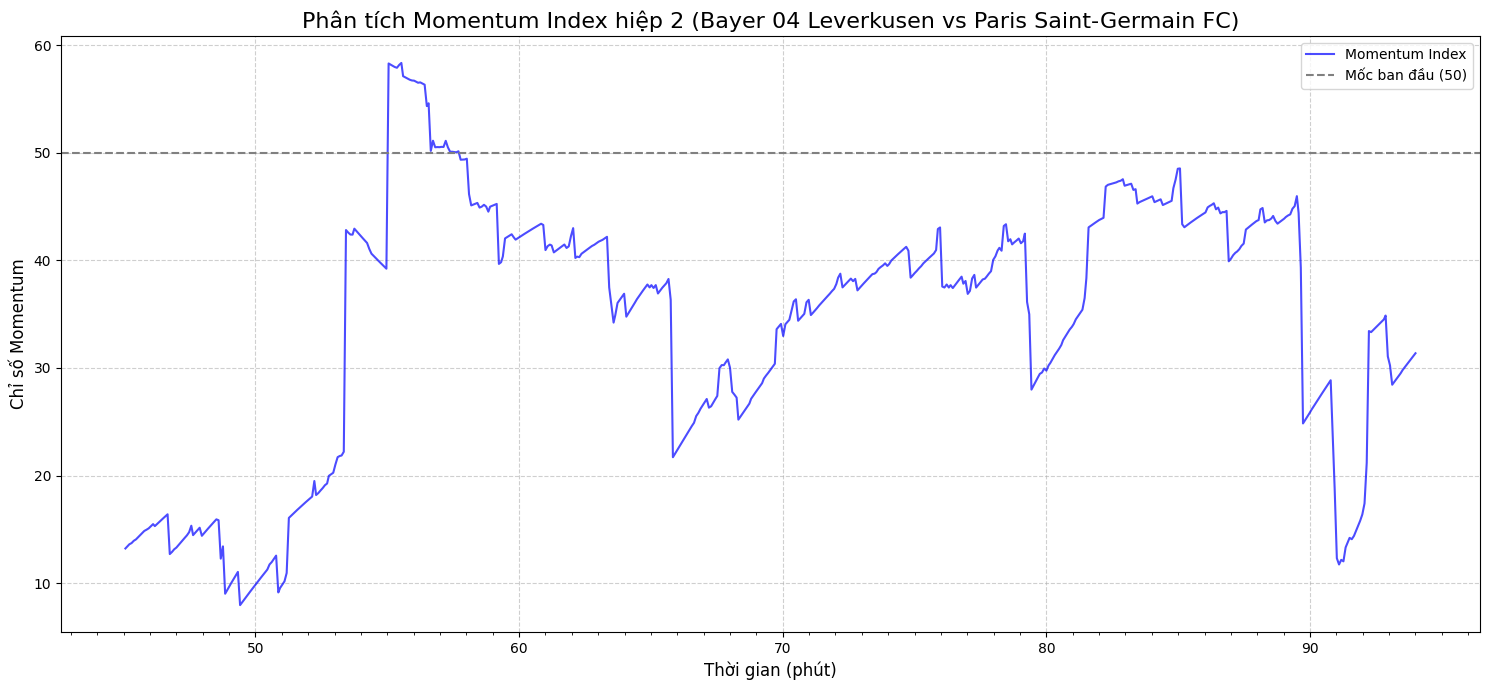

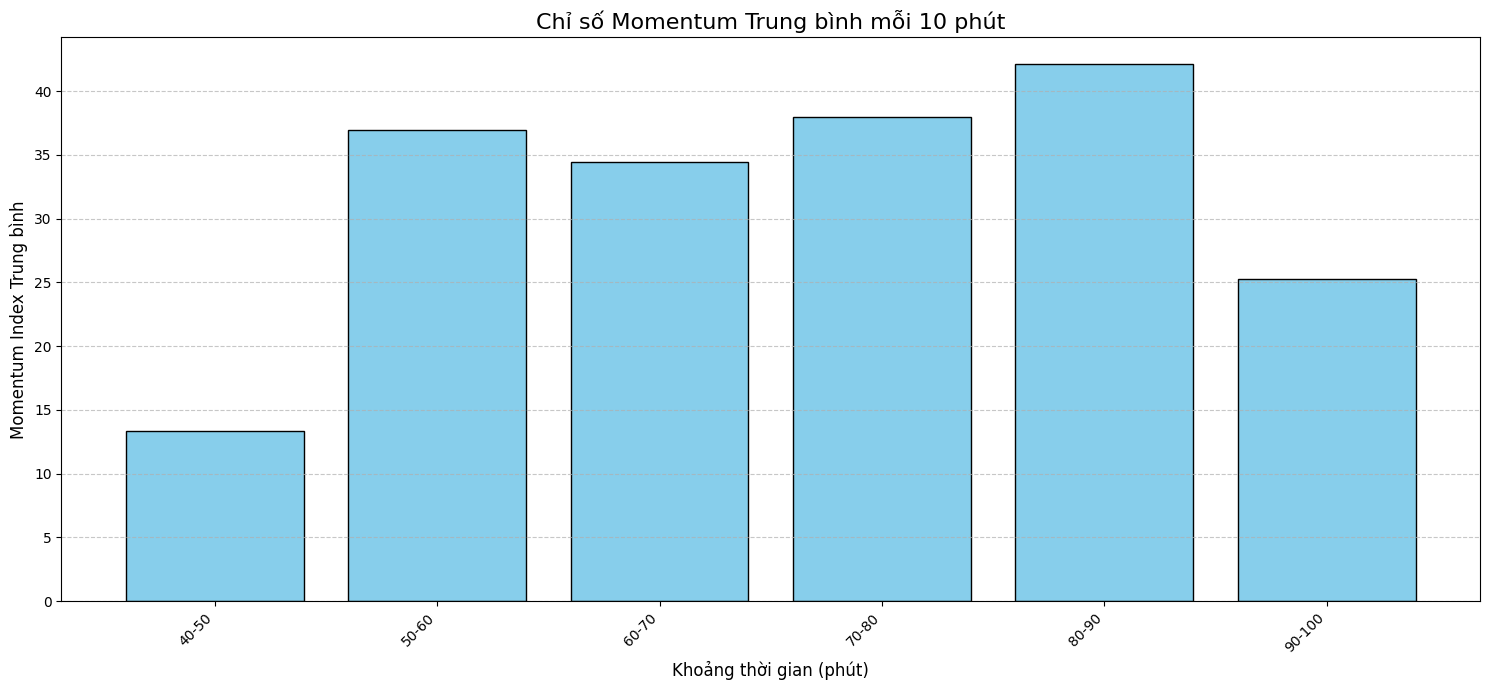

In [4]:



# 2. Tải và chuẩn bị dữ liệu
try:
    df = pd.read_json('momentum_index_second_half.json')
    print("Tải dữ liệu thành công.")
    
    # Áp dụng hàm chuyển đổi thời gian
    df['total_seconds'] = df['time_in_match'].apply(parse_time_to_seconds)
    df['total_minutes'] = df['total_seconds'] / 60
    
    # Sắp xếp lại dữ liệu theo thời gian (quan trọng cho biểu đồ đường)
    df = df.sort_values(by='total_seconds').reset_index(drop=True)

    # Phát hiện và lọc các giá trị ngoại lệ (outliers)
    # Có một giá trị -80225.97 rất lớn, ta sẽ lọc nó
    df_filtered = df[df['momentum_index'] > -10000].copy()
    print(f"Dữ liệu gốc có {len(df)} điểm. Dữ liệu sau khi lọc ngoại lệ có {len(df_filtered)} điểm.")

    # 3. Biểu đồ 1: Visualize toàn bộ trận đấu
    plt.figure(figsize=(15, 7))
    plt.plot(df_filtered['total_minutes'], df_filtered['momentum_index'], label='Momentum Index', color='blue', alpha=0.7)
    
    # Thêm đường 50 (mốc bắt đầu)
    plt.axhline(y=50, color='grey', linestyle='--', label='Mốc ban đầu (50)')
    
    # Định dạng trục x để hiển thị phút rõ ràng
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
    plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(1))

    plt.title(f'Phân tích Momentum Index hiệp 2 ({match_config.home_team} vs {match_config.away_team})', fontsize=16)
    plt.xlabel('Thời gian (phút)', fontsize=12)
    plt.ylabel('Chỉ số Momentum', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig('momentum_full_match_second_half.png')
    print("Đã lưu biểu đồ toàn trận vào 'momentum_full_match_second_half.png'")

    # 4. Biểu đồ 2: Visualize theo khoảng 10 phút (trung bình)
    
    # Tạo các khoảng 10 phút (600 giây)
    max_seconds = int(df_filtered['total_seconds'].max())
    # Đảm bảo bin cuối cùng bao gồm cả điểm dữ liệu cuối cùng
    bins = list(range(0, max_seconds + 600, 600))
    
    # Tạo nhãn cho các khoảng, ví dụ: "0-10", "10-20"
    labels = [f'{i // 60}-{(i + 600) // 60}' for i in bins[:-1]]
    
    # Thêm cột 'time_bin' vào dataframe đã lọc
    df_filtered['time_bin'] = pd.cut(df_filtered['total_seconds'], bins=bins, labels=labels, right=False)
    
    # Tính toán momentum trung bình cho mỗi khoảng thời gian
    summary_df = df_filtered.groupby('time_bin')['momentum_index'].mean().reset_index()

    # Vẽ biểu đồ cột
    plt.figure(figsize=(15, 7))
    plt.bar(summary_df['time_bin'], summary_df['momentum_index'], color='skyblue', edgecolor='black')
    
    plt.title('Chỉ số Momentum Trung bình mỗi 10 phút', fontsize=16)
    plt.xlabel('Khoảng thời gian (phút)', fontsize=12)
    plt.ylabel('Momentum Index Trung bình', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('momentum_10min_intervals_second_half.png')
    print("Đã lưu biểu đồ 10 phút vào 'momentum_10min_intervals_second_half.png'")

except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'momentum_index_second_half.json'.")
except Exception as e:
    print(f"Đã xảy ra lỗi: {e}")